In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from alea.models.blueice_extended_model import BlueiceExtendedModel

Welcome to JupyROOT 6.30/02


In [98]:
def half_life_from_events(
    Nsig,
    mass_kg=1000,
    livetime_yr=1,
    enrichment=0.90,
    efficiency=1.0,
):
    NA = 6.02214076e23  # mol^-1
    m136_g_per_mol = 135.907214  # Xe-136 molar mass

    mass_g = mass_kg * 1000

    N_xe136 = mass_g * enrichment / m136_g_per_mol * NA

    T12 = np.log(2) * N_xe136 * efficiency * livetime_yr / Nsig

    return T12

INFO:root:Load bkg_template.ii.h5 successfully from /srv01/xenon/jacquesp/alea/alea/examples/templates/bkg_template.ii.h5
INFO:root:Load bkg_template.ii.h5 successfully from /srv01/xenon/jacquesp/alea/alea/examples/templates/bkg_template.ii.h5
INFO:root:Load xe136_2vbb_template.ii.h5 successfully from /srv01/xenon/jacquesp/alea/alea/examples/templates/xe136_2vbb_template.ii.h5
INFO:root:Load xe136_2vbb_template.ii.h5 successfully from /srv01/xenon/jacquesp/alea/alea/examples/templates/xe136_2vbb_template.ii.h5
INFO:root:Load xe136_0vbb_template.ii.h5 successfully from /srv01/xenon/jacquesp/alea/alea/examples/templates/xe136_0vbb_template.ii.h5
INFO:root:Load xe136_0vbb_template.ii.h5 successfully from /srv01/xenon/jacquesp/alea/alea/examples/templates/xe136_0vbb_template.ii.h5


from cache? True
from cache? True
from cache? True
from cache? True
from cache? True
from cache? True


Toys @ 20.0 yr: 100%|█████████████████████████████████████████████████████████████████| 300/300 [01:43<00:00,  2.89it/s]


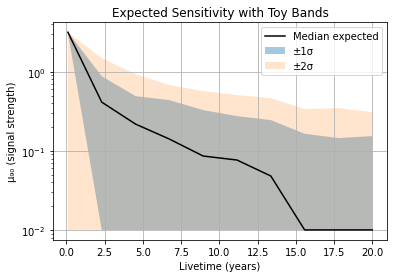

In [113]:
# -----------------------------
# Load model
# -----------------------------
config_path = "/srv01/xenon/jacquesp/alea/alea/examples/configs/binned_ces_0vbb.yaml"
model = BlueiceExtendedModel.from_config(config_path)

# -----------------------------
# Exposure grid
# -----------------------------
livetime_years_list = np.linspace(0.1, 20, 10)
bkg_rate = model.parameters["bkg_rate_multiplier"]._nominal_value*0.5
# number of toys per exposure
N_Toys = 300   # increase to 200–500 for final result

# storage
median_curve = []
p16, p84 = [], []
p025, p975 = [], []

# -----------------------------
# Loop over exposures
# -----------------------------
for t in livetime_years_list:


    model.parameters["livetime"].nominal_value = t * 365

    mu90_toys = []

    # -----------------------------
    # Toy loop
    # -----------------------------
    for i in tqdm(range(N_Toys), desc=f"Toys @ {t:.1f} yr"):

        # Asimov / background-only toy
        model.data = model.generate_data(signal_rate_multiplier=0, bkg_rate_multiplier=bkg_rate)

        # Fit for μ̂ and L̂
        best_fit, ll_hat = model.fit()

        # scan grid in μ
        mus = np.logspace(-2, 0.5, 100)

        ll_vals = np.array([
            model.ll(signal_rate_multiplier=mu)
            for mu in mus
        ])

        muhat = best_fit["signal_rate_multiplier"]

        #One-sided construction
        q_mu = -2 * (ll_vals - ll_hat)
        q_mu[mus < muhat] = 0

        idx = np.where(q_mu >= 2.71)[0]

        if len(idx) == 0:
            mu90 = mus[-1]
        else:
            mu90 = mus[idx[0]]

        mu90_toys.append(mu90)

    # -----------------------------
    # Statistics of toys
    # -----------------------------
    mu90_toys = np.array(mu90_toys)

    median_curve.append(np.median(mu90_toys))
    p16.append(np.percentile(mu90_toys, 16))
    p84.append(np.percentile(mu90_toys, 84))
    p025.append(np.percentile(mu90_toys, 2.5))
    p975.append(np.percentile(mu90_toys, 97.5))

# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.plot(livetime_years_list, median_curve, label="Median expected", color="black")

plt.fill_between(livetime_years_list, p16, p84, alpha=0.4, label="±1σ")
plt.fill_between(livetime_years_list, p025, p975, alpha=0.2, label="±2σ")

plt.xlabel("Livetime (years)")
plt.ylabel("μ₉₀ (signal strength)")
plt.yscale("log")
plt.legend()
plt.grid()
plt.title("Expected Sensitivity with Toy Bands")
plt.show()

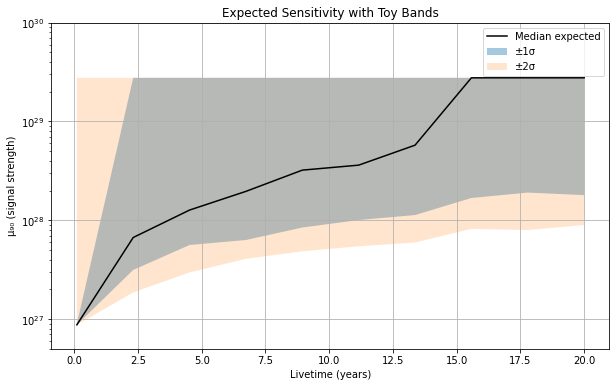

In [114]:
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(livetime_years_list, half_life_from_events(median_curve), label="Median expected", color="black")

plt.fill_between(livetime_years_list, 
                 half_life_from_events(p16), 
                 half_life_from_events(p84),
                 alpha=0.4, label="±1σ")
plt.fill_between(livetime_years_list, 
                 half_life_from_events(p025), 
                 half_life_from_events(p975),
                 alpha=0.2, label="±2σ")

plt.xlabel("Livetime (years)")
plt.ylabel("μ₉₀ (signal strength)")
plt.yscale("log")
plt.legend()
plt.grid()
plt.ylim(0.5e27, 1e30)
plt.title("Expected Sensitivity with Toy Bands")
plt.show()

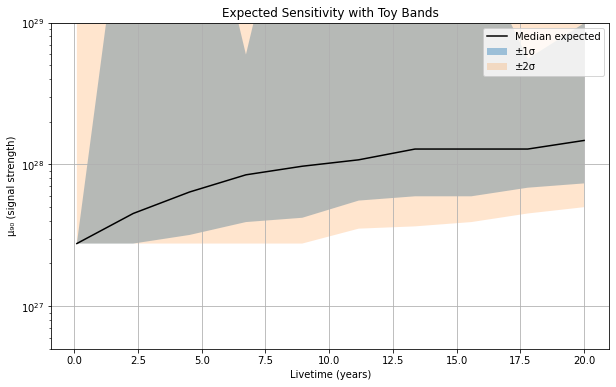

In [106]:
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(livetime_years_list, half_life_from_events(median_curve), label="Median expected", color="black")

plt.fill_between(livetime_years_list, 
                 half_life_from_events(p16), 
                 half_life_from_events(p84),
                 alpha=0.4, label="±1σ")
plt.fill_between(livetime_years_list, 
                 half_life_from_events(p025), 
                 half_life_from_events(p975),
                 alpha=0.2, label="±2σ")

plt.xlabel("Livetime (years)")
plt.ylabel("μ₉₀ (signal strength)")
plt.yscale("log")
plt.legend()
plt.grid()
plt.ylim(0.5e27, 1e29)
plt.title("Expected Sensitivity with Toy Bands")
plt.show()

In [82]:
#For discovery:
#model.generate_data(signal_rate_multiplier=mu_true)
#q0 = -2*(ll_bkg_only - ll_bestfit)
#3sigma
#Signal strength at which 50% of toys exceed q0>9

In [190]:
model.parameters["livetime"].nominal_value = 10 * 365
bkg_rate = model.parameters["bkg_rate_multiplier"]._nominal_value*1.0
# Asimov / background-only toy
model.data = model.generate_data(signal_rate_multiplier=0, bkg_rate_multiplier=bkg_rate)

# Fit for μ̂ and L̂
best_fit, ll_hat = model.fit()

# scan grid in μ
mus = np.logspace(-2.5, 1, 200)

ll_vals = np.array([
    model.ll(signal_rate_multiplier=mu)
    for mu in mus
])

muhat = best_fit["signal_rate_multiplier"]

#One-sided construction
q_mu = -2 * (ll_vals - ll_hat)
#q_mu[mus < muhat] = 0

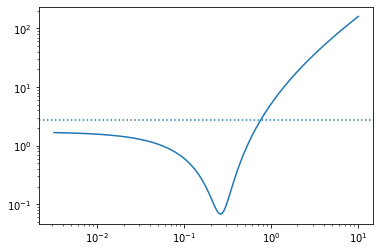

In [186]:
plt.plot(mus, q_mu)
plt.axhline([2.71], linestyle=':')
plt.xscale('log')
plt.yscale('log')

In [121]:
idx = np.where(q_mu >= 2.71)[0]

if len(idx) == 0:
    mu90 = mus[-1]
else:
    mu90 = mus[idx[0]]

In [192]:
mu90

3.1622776601683795